In [1]:
from EpiClockNBL.site_selection import save_unbiased_sites, select_fCpGs
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import os
import numpy as np
import pandas as pd
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts

proj_dir = os.path.join(nbl_consts['official_indir'], 'TARGET')

Running save-unbiased-sites pipeline with verbose=True, make_figures=True.
Saving figures to c:\Users\DanMonyak\Documents\RyserLab\EpiClockNBL\figures_revision
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data, will take 2-30 min... DONE

Select unbiased sites...

Selecting CpGs with:
	157 TCGA samples

DONE

Generating figure...

Selecting CpGs with:
	157 TCGA samples

DONE


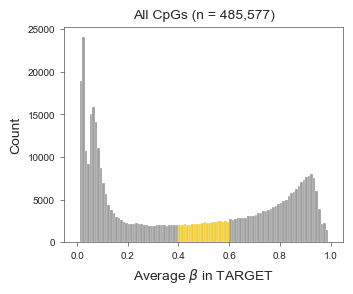

In [ ]:
save_unbiased_sites.pipeline(make_figures=True)


Running select-fCpGs pipeline with verbose=True, make_figures=True.
Saving figures to c:\Users\DanMonyak\Documents\RyserLab\EpiClockNBL\figures_revision
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data...

Starting with 41356 balanced sites

DONE

Importing clinical table... DONE

Removing sites that correlate with patient age...



100%|██████████| 41356/41356 [00:47<00:00, 865.04it/s] 


Picked 19128 non-age-correlated sites

DONE

Selecting final sites...

Picking 1000 target sites
Picked 14346 not stuck sites
Current output matches existing file.
Current output matches existing file.

DONE

Generating figure... DONE

Generating figure... DONE


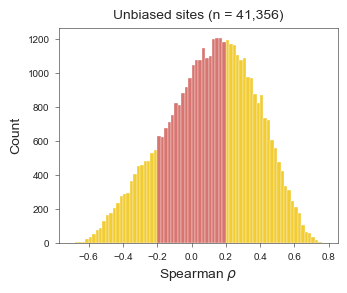

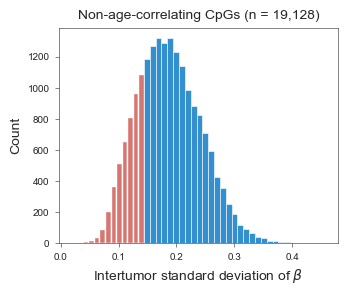

In [3]:
select_fCpGs.pipeline(make_figures=True)

## Sensitivity analysis

### Split in half

In [3]:
sensitivity_analysis_dir = os.path.join(proj_dir, 'selection_sensitivity_analysis')
os.makedirs(sensitivity_analysis_dir, exist_ok=True)

split_filenames=['beta_values_unbiased_sites_split1.txt', 'beta_values_unbiased_sites_split2.txt']

sensitivity_analysis_split1_dir = os.path.join(sensitivity_analysis_dir, 'split1')
sensitivity_analysis_split2_dir = os.path.join(sensitivity_analysis_dir, 'split2')
os.makedirs(sensitivity_analysis_split1_dir, exist_ok=True)
os.makedirs(sensitivity_analysis_split2_dir, exist_ok=True)

output_dir = os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs')
output_dir_split1 = os.path.join(output_dir, 'split1')
output_dir_split2 = os.path.join(output_dir, 'split2')
os.makedirs(output_dir_split1, exist_ok=True)
os.makedirs(output_dir_split2, exist_ok=True)


In [2]:
save_unbiased_sites.pipeline(make_figures=False, random_split=True, random_seed=0, outdir=sensitivity_analysis_dir, filenames=split_filenames)

Running save-unbiased-sites pipeline with verbose=True, make_figures=False.
Set make_figures=True to generate the accompanying figures.
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data, will take 2-30 min... DONE

Select unbiased sites...

Splitting tumors into two random groups for sensitivity analysis
Selecting unbiased sites in group 0
Selecting CpGs with:
	79 TCGA samples
Selecting unbiased sites in group 1
Selecting CpGs with:
	78 TCGA samples

DONE


In [5]:
select_fCpGs.pipeline(make_figures=False, output_dir=output_dir_split1, outdir=sensitivity_analysis_split1_dir, indir=sensitivity_analysis_dir, beta_values_unbiased_sites_filename=split_filenames[0])
select_fCpGs.pipeline(make_figures=False, output_dir=output_dir_split2, outdir=sensitivity_analysis_split2_dir, indir=sensitivity_analysis_dir, beta_values_unbiased_sites_filename=split_filenames[1])


Running select-fCpGs pipeline with verbose=True, make_figures=False.
Set make_figures=True to generate the accompanying figures.
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data...

Starting with 41890 balanced sites

DONE

Importing clinical table... DONE

Removing sites that correlate with patient age...



100%|██████████| 41890/41890 [01:14<00:00, 561.15it/s] 


Picked 18834 non-age-correlated sites

DONE

Selecting final sites...

Picking 1000 target sites
Picked 14125 not stuck sites

DONE

Running select-fCpGs pipeline with verbose=True, make_figures=False.
Set make_figures=True to generate the accompanying figures.
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data...

Starting with 40908 balanced sites

DONE

Importing clinical table... DONE

Removing sites that correlate with patient age...



100%|██████████| 40908/40908 [01:17<00:00, 530.76it/s]


Picked 18414 non-age-correlated sites

DONE

Selecting final sites...

Picking 1000 target sites
Picked 13810 not stuck sites

DONE


In [4]:
# Import split1 and split2 fCpG sets, and save the beta values for all tumors

split1_fCpGs = np.loadtxt(os.path.join(output_dir_split1, 'NBL_Clock_CpGs.txt'), dtype='str')
split2_fCpGs = np.loadtxt(os.path.join(output_dir_split2, 'NBL_Clock_CpGs.txt'), dtype='str')
beta_values_full = pd.read_table(os.path.join(proj_dir, 'cohort1.methyl.tsv'))

# ----------------

split1_fCpGs_outfile_path = os.path.join(output_dir_split1, 'beta_values_all_tumors_split1_sites.tsv')
split2_fCpGs_outfile_path = os.path.join(output_dir_split2, 'beta_values_all_tumors_split2_sites.tsv')


nbl_util.writeWithoutOverwrite(
    split1_fCpGs_outfile_path,
    beta_values_full.loc[split1_fCpGs],
    lambda filepath, data: data.to_csv(filepath, sep='\t'),
    lambda filepath: pd.read_table(filepath, index_col=0),
    compareFunc=lambda old, new: (old.round(5).fillna(0) == new.round(5).fillna(0)).all(axis=None, skipna=True)
)
nbl_util.writeWithoutOverwrite(
    split2_fCpGs_outfile_path,
    beta_values_full.loc[split2_fCpGs],
    lambda filepath, data: data.to_csv(filepath, sep='\t'),
    lambda filepath: pd.read_table(filepath, index_col=0),
    compareFunc=lambda old, new: (old.round(5).fillna(0) == new.round(5).fillna(0)).all(axis=None, skipna=True)
)

Current output matches existing file.
c:\Users\DanMonyak\Documents\RyserLab\EpiClockNBL\3. Select fCpGs\outputs\split1\beta_values_all_tumors_split1_sites.tsv
Current output matches existing file.
c:\Users\DanMonyak\Documents\RyserLab\EpiClockNBL\3. Select fCpGs\outputs\split2\beta_values_all_tumors_split2_sites.tsv
